# QCD Feynman Diagram to Squared Amplitude Ablation


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def _find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Specific Task 2.1").exists() and (candidate / "dataset").exists():
            return candidate
    return cwd


def setup_environment() -> tuple[Path, Path]:
    input_dir = Path("/kaggle/input")
    working_dir = Path("/kaggle/working")

    if input_dir.exists():
        data_files = list(input_dir.rglob("QCD-2-to-2-diag-TreeLevel-*.txt"))
        if not data_files:
            raise FileNotFoundError("Could not find QCD dataset files under /kaggle/input.")
        data_dir = data_files[0].parent

        parser_files = list(input_dir.rglob("custom_qcd_fd2sq/parser.py"))
        if parser_files:
            package_root = parser_files[0].parent.parent
            if str(package_root) not in sys.path:
                sys.path.insert(0, str(package_root))
        working_dir = working_dir / "kaggle_custom_qcd_fd2sq"
    else:
        repo_root = _find_repo_root()
        package_root = repo_root / "Specific Task 2.1"
        if str(package_root) not in sys.path:
            sys.path.insert(0, str(package_root))
        data_dir = repo_root / "dataset"
        working_dir = repo_root / "outputs" / "kaggle_custom_qcd_fd2sq"

    working_dir.mkdir(parents=True, exist_ok=True)
    return data_dir, working_dir


data_dir, working_dir = setup_environment()
pd.set_option("display.max_colwidth", 240)
plt.rcParams["figure.figsize"] = (8, 4)
print(f"Data directory: {data_dir}")
print(f"Working directory: {working_dir}")


Data directory: /kaggle/input/datasets/nextsmallestml/qcd-dataset
Working directory: /kaggle/working/kaggle_custom_qcd_fd2sq


## Target Variants

I keep two decoder targets.

- `factorized`: I simplify the squared amplitude using SymPy and write it as `(color_factor)*((numerator)/(denominator))`. The model predicts that full symbolic target autoregressively as one postfix sequence under the physics-informed grammar, while keeping numeric prefactors such as `16/9` or `2/3` as single literal tokens.
- `raw_string`: I decode the original raw SYMBA squared-amplitude string as a postfix sequence under the same physics-informed grammar, again keeping rational constants such as `1/6` or `1/2304` intact as single literal tokens instead of expanding them digit by digit. I have also tried expanding digit by digit use wrapping but I guess we need more data for it to learn meaningfully and generalise. 

The custom PI-GNN encoder runs message passing on the parsed QCD Feynman-diagram graph, with separate color, kinematic, and spinor streams before the decoder attends to the fused diagram memory. So the factorized branch stays a next-token model from end to end.

The symbolic factorisation I use here follows the basis-oriented amplitude literature cited in the observation cell below, especially Dixon (1996), Del Duca-Dixon-Maltoni (1999), Johansson-Ochirov (2015), and Catani (1998).

While examining the dataset, I noticed that many of the target expressions admit substantial algebraic simplification. This motivated me to study a factorized prediction target for squared amplitudes. The underlying factorization idea is well established in scattering-amplitude physics, but, to the best of my knowledge, its use as a decoder-target design for squared-amplitude prediction has not been explored in prior ML work. The simplification is especially helpful here because the raw QCD squared-amplitude strings are much longer than the factorized targets.



## Input Handling

I start from the raw SYMBA diagram text. The custom path parses each sample into a PyG Feynman graph with physics-labelled nodes and relation-aware edges, while the seq2seq baseline uses the same parsed diagram but linearises its channel, external-particle, vertex, and propagator metadata into a source sequence. Both models decode the same squared-amplitude target. All four runs in this notebook use the same fixed 80/10/10 split with seed 42.


In [2]:
from statistics import mean

from custom_qcd_fd2sq.config import CustomQCDFd2SqConfig
from custom_qcd_fd2sq.factorization import (
    TARGET_VARIANT_FACTORIZED,
    TARGET_VARIANT_RAW_STRING,
    factorize_squared_amplitude,
)
from custom_qcd_fd2sq.parser import parse_all_qcd
from custom_qcd_fd2sq.tokenizer import AmplitudeTokenizer
from custom_qcd_fd2sq.runtime import ensure_torch_geometric

ensure_torch_geometric(auto_install=True)

from custom_qcd_fd2sq.train import CustomQCDFd2SqTrainer

VARIANTS = [('custom', 'custom'), ('seq2seq', 'seq2seq')]
TARGET_SPECS = [
    {
        "target_variant": TARGET_VARIANT_FACTORIZED,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
    {
        "target_variant": TARGET_VARIANT_RAW_STRING,
        "decoder_representation": "postfix",
        "use_grammar": True,
    },
]
TARGET_SPEC_MAP = {spec["target_variant"]: spec for spec in TARGET_SPECS}
SHARED_SPLIT_SEED = 42
SUMMARY_COLUMNS = [
    "target_variant",
    "variant_name",
    "encoder_variant",
    "max_target_len",
    "split_seed",
    "test_seq_accuracy",
]


def encoded_target_length(expr: str, expression_mode: str) -> int:
    tokenizer = AmplitudeTokenizer(expression_mode=expression_mode)
    return 2 + len(tokenizer.tokenize_expr(expr))


def write_markdown_table(df: pd.DataFrame, path: Path, title: str) -> Path:
    lines = [f"# {title}", ""]
    lines.append("| " + " | ".join(df.columns) + " |")
    lines.append("| " + " | ".join(["---"] * len(df.columns)) + " |")
    for row in df.to_dict(orient="records"):
        rendered = []
        for column in df.columns:
            value = row[column]
            if isinstance(value, float):
                rendered.append(f"{value:.3f}")
            else:
                rendered.append(str(value))
        lines.append("| " + " | ".join(rendered) + " |")
    path.write_text("\n".join(lines) + "\n")
    return path


def target_length_stats(current_data_dir: Path | str, target_variant: str) -> dict[str, float]:
    spec = TARGET_SPEC_MAP[target_variant]
    diagrams = parse_all_qcd(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=target_variant)
        for diagram in diagrams
    ]
    lengths = [
        encoded_target_length(target.sequence_target_text(), spec["decoder_representation"])
        for target in targets
    ]
    return {
        "target_variant": target_variant,
        "decoder_representation": spec["decoder_representation"],
        "min": min(lengths),
        "avg": round(mean(lengths), 2),
        "max": max(lengths),
        "max_with_margin": max(lengths) + 16,
    }


def build_example_tables(current_data_dir: Path | str) -> tuple[pd.DataFrame, pd.DataFrame]:
    diagram = parse_all_qcd(current_data_dir)[0]
    raw_squared = diagram.raw_squared
    factorized_target = factorize_squared_amplitude(
        raw_squared,
        target_variant=TARGET_VARIANT_FACTORIZED,
    )
    factorization_example = pd.DataFrame(
        [
            {
                "example_process": " ".join(f"{'in' if particle.is_incoming else 'out'}:{particle.flavor}{'bar' if particle.is_antiparticle else ''}" for particle in diagram.externals),
                "color_factor": getattr(factorized_target, "color_factor"),
                "denominator": factorized_target.denominator.replace("**", "^"),
                "numerator": factorized_target.numerator_infix,
                "factorized_sequence": factorized_target.full_infix,
                "raw_string": factorized_target.raw_string,
            }
        ]
    )

    representation_examples = []
    for spec in TARGET_SPECS:
        target = factorize_squared_amplitude(
            raw_squared,
            target_variant=spec["target_variant"],
        )
        representation_examples.append(
            {
                "target_variant": spec["target_variant"],
                "decoder_representation": spec["decoder_representation"],
                "use_grammar": spec["use_grammar"],
                "sequence_target": target.sequence_target_text(),
            }
        )
    return factorization_example, pd.DataFrame(representation_examples)


def observation_summary(current_data_dir: Path | str) -> pd.DataFrame:
    diagrams = parse_all_qcd(current_data_dir)
    targets = [
        factorize_squared_amplitude(diagram.raw_squared, target_variant=TARGET_VARIANT_FACTORIZED)
        for diagram in diagrams
    ]
    factors = sorted({getattr(target, "color_factor") for target in targets})
    denominators = sorted({target.denominator.replace("**", "^") for target in targets})
    return pd.DataFrame(
        [
            {
                "num_samples": len(targets),
                "unique_color_factors": len(factors),
                "unique_denominators": len(denominators),
            }
        ]
    )


def build_variant_config(
    current_data_dir: Path,
    current_working_dir: Path,
    *,
    target_variant: str,
    variant_name: str,
    encoder_variant: str,
    max_target_len: int,
):
    spec = TARGET_SPEC_MAP[target_variant]
    config = CustomQCDFd2SqConfig()
    config.data.data_dir = str(current_data_dir)
    config.data.target_variant = target_variant
    config.output_dir = str(current_working_dir / target_variant / variant_name)
    config.experiment_name = f"{target_variant}_{variant_name}"

    config.training.max_epochs = 500 if target_variant == TARGET_VARIANT_RAW_STRING else 250
    config.training.stop_on_val_exact = None
    config.training.stop_on_test_exact = None
    config.training.batch_size = 16
    config.training.learning_rate = 3e-4
    config.training.weight_decay = 1e-5
    config.training.warmup_epochs = 10
    config.training.min_lr = 1e-6
    config.training.gradient_clip = 1.0
    config.training.seed = SHARED_SPLIT_SEED
    config.training.num_workers = 2
    config.training.log_every_n_steps = 10
    if hasattr(config.data, "augment_kinematics"):
        config.data.augment_kinematics = False
    if hasattr(config.data, "num_kinematic_samples"):
        config.data.num_kinematic_samples = 1

    config.model.hidden_dim = 128
    if hasattr(config.model, "stream_dim"):
        config.model.stream_dim = 64
    if hasattr(config.model, "graph_dim"):
        config.model.graph_dim = 128
    if hasattr(config.model, "slot_dim"):
        config.model.slot_dim = 64
    if hasattr(config.model, "channel_prop_dim"):
        config.model.channel_prop_dim = 64
    if hasattr(config.model, "fermion_line_dim"):
        config.model.fermion_line_dim = 64
    if hasattr(config.model, "static_charge_dim"):
        config.model.static_charge_dim = 64
    if hasattr(config.model, "memory_dim"):
        config.model.memory_dim = 64
    config.model.num_mp_layers = 3
    config.model.num_heads = 4
    config.model.dropout = 0.1
    config.model.dec_d_model = 256
    config.model.dec_nhead = 4
    config.model.dec_layers = 4
    config.model.dec_dim_ff = 512
    config.model.max_seq_len = max_target_len
    if hasattr(config.model, "max_src_seq_len"):
        config.model.max_src_seq_len = 256
    config.model.max_gen_len = max_target_len
    config.model.encoder_variant = encoder_variant
    config.model.decoder_representation = spec["decoder_representation"]
    config.model.use_grammar = spec["use_grammar"]
    return config


def _clean_curve(values):
    return [float("nan") if value is None else float(value) for value in values]


def plot_suite_losses(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "loss_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["train_loss"]) + 1))
        ax.plot(epochs, _clean_curve(history["train_loss"]), label="train loss")
        ax.plot(epochs, _clean_curve(history["val_loss"]), label="val loss")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_loss_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def plot_suite_accuracies(target_variant: str, results_df: pd.DataFrame, histories: dict[str, dict]) -> Path:
    plot_dir = working_dir / "accuracy_curves"
    plot_dir.mkdir(parents=True, exist_ok=True)
    fig, axes = plt.subplots(1, len(results_df), figsize=(6 * len(results_df), 4), squeeze=False)
    axes = axes[0]
    for ax, row in zip(axes, results_df.to_dict(orient="records")):
        history = histories[row["variant_name"]]
        epochs = list(range(1, len(history["val_seq_accuracy"]) + 1))
        ax.plot(epochs, _clean_curve(history["val_seq_accuracy"]), label="val seq accuracy")
        ax.set_title(f"{row['encoder_variant']} ({target_variant})")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Validation sequence accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    path = plot_dir / f"{target_variant}_accuracy_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def run_suite(target_variant: str) -> tuple[pd.DataFrame, dict[str, dict]]:
    target_len = max(target_length_stats(data_dir, target_variant)["max_with_margin"], 128)
    results = []
    histories = {}
    for variant_name, encoder_variant in VARIANTS:
        config = build_variant_config(
            data_dir,
            working_dir,
            target_variant=target_variant,
            variant_name=variant_name,
            encoder_variant=encoder_variant,
            max_target_len=target_len,
        )
        trainer = CustomQCDFd2SqTrainer(config)
        history = trainer.train()
        metrics = trainer.evaluate()
        histories[variant_name] = history
        results.append(
            {
                "target_variant": target_variant,
                "variant_name": variant_name,
                "encoder_variant": encoder_variant,
                "max_target_len": target_len,
                "split_seed": SHARED_SPLIT_SEED,
                "test_seq_accuracy": metrics["test_seq_accuracy"],
                "test_loss": metrics["test_loss"],
            }
        )
    return pd.DataFrame(results), histories


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 43.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 41.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 403.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 507.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 141.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 493.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 kB 483.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 225.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 461.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 466.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy

## Example

QCD squared-amplitude sample decomposes into its `color_factor`, denominator, numerator, and the two sequence targets I actually compare.


In [3]:
example_factor_df, example_target_df = build_example_tables(data_dir)
display(example_factor_df)
display(example_target_df)


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,example_process,color_factor,denominator,numerator,factorized_sequence,raw_string
0,in:u in:ubar out:d out:dbar,16/9,(2*m_u^2 + reg_prop + 2*s_12)^2,2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23,(16/9)*((2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2)),-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...


,target_variant,decoder_representation,use_grammar,sequence_target
0,factorized,postfix,True,(16/9)*((2*m_d^2*m_u^2 + m_d^2*s_12 + m_u^2*s_34 + s_13*s_24 + s_14*s_23)/((2*m_u^2 + reg_prop + 2*s_12)^2))
1,raw_string,postfix,True,-1/144*g^4*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_u^2*s_34)*(m_u^2 + s_12 + 1/2*reg_prop)^(-2) + 1/16*i*g^2*(i*g^2*((-16)*m_d^2*m_u^2 + (-8)*m_d^2*s_12 + (-8)*s_14*s_23 + (-8)*s_13*s_24 + (-8)*m_...


## Target 



In [4]:
target_stats = pd.DataFrame(
    [target_length_stats(data_dir, spec["target_variant"]) for spec in TARGET_SPECS]
)
display(target_stats)


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,target_variant,decoder_representation,min,avg,max,max_with_margin
0,factorized,postfix,41,48.64,68,84
1,raw_string,postfix,86,328.49,1226,1242


## Monitoring Policy

For the factorized target, I decode only the validation split during training, so the accuracy curve shows validation sequence accuracy only. I select the best checkpoint by highest validation sequence accuracy with validation loss as the tie-breaker.

For the raw-string target, I do not run autoregressive decoding during training. I select the best checkpoint by minimum validation loss and compute exact test sequence accuracy only once at the end from that best-loss checkpoint. This is a standard teacher-forced model-selection choice for very long symbolic targets, and it keeps training time tractable. This is because calculating val_seq_accuracy and train_seq_accuracy every epoch leads to about 300s training time per epoch for the custom graph encoder on NVIDIA H100.


## Factorized Runs


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Using device: cuda
Loading QCD data from /kaggle/input/datasets/nextsmallestml/qcd-dataset...
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Loaded 234 diagrams
Factorizing squared amplitudes...
Tokenizer numerator vocab size: 33 (postfix)
  S

/kaggle/input/datasets/nextsmallestml/qcd-feytosq/custom_qcd_fd2sq/sequence_encoder.py:67: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 0001 | train 3.3939 | val 1.7918 / seq 0.000 | improved | 0.8s
Epoch 0002 | train 1.8171 | val 1.5393 / seq 0.000 | improved | 1.6s
Epoch 0003 | train 1.5513 | val 1.2026 / seq 0.000 | improved | 2.5s
Epoch 0004 | train 1.2636 | val 0.9765 / seq 0.000 | improved | 3.3s
Epoch 0005 | train 1.0061 | val 0.7473 / seq 0.000 | improved | 4.2s
Epoch 0010 | train 0.3017 | val 0.1945 / seq 0.043 | improved | 8.5s
Epoch 0020 | train 0.0463 | val 0.0684 / seq 0.522 | 17.5s
Epoch 0030 | train 0.0203 | val 0.0398 / seq 0.739 | 26.2s
Epoch 0040 | train 0.0139 | val 0.0243 / seq 0.696 | 34.7s
Epoch 0050 | train 0.0149 | val 0.0300 / seq 0.739 | 43.1s
Epoch 0060 | train 0.0100 | val 0.0342 / seq 0.739 | 51.5s
Epoch 0070 | train 0.0098 | val 0.0311 / seq 0.739 | 59.8s
Epoch 0080 | train 0.0085 | val 0.0292 / seq 0.739 | 68.3s
Epoch 0090 | train 0.0078 | val 0.0283 / seq 0.739 | 77.0s
Epoch 0100 | train 0.0074 | val 0.0273 / seq 0.696 | 85.3s
Epoch 0110 | train 0.0075 | val 0.0255 / seq 0.696 | 93

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,custom,custom,128,42,1.000000
1,factorized,seq2seq,seq2seq,128,42,0.791667


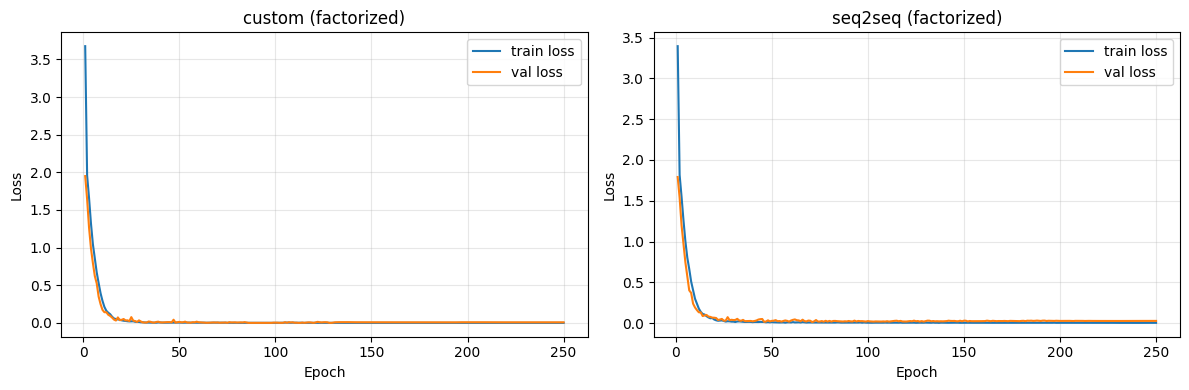

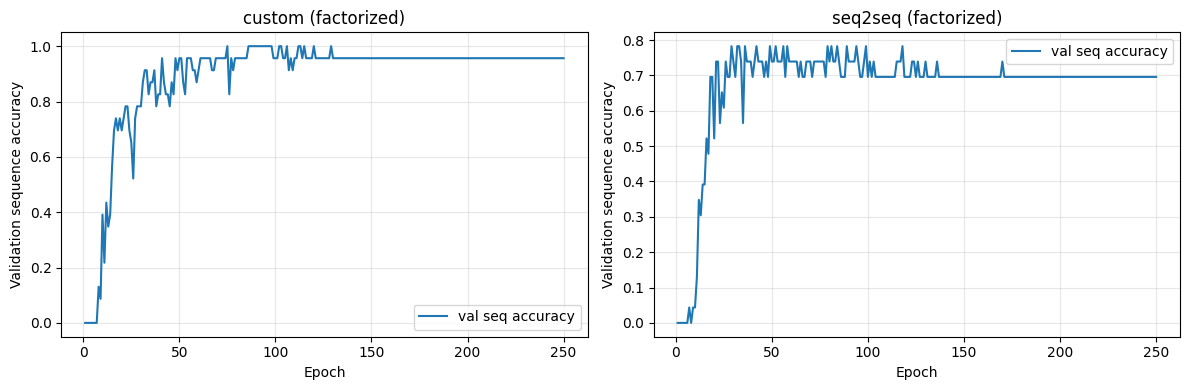

PosixPath('/kaggle/working/kaggle_custom_qcd_fd2sq/accuracy_curves/factorized_accuracy_curves.png')

In [5]:
factorized_results, factorized_histories = run_suite(TARGET_VARIANT_FACTORIZED)
display(factorized_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)
plot_suite_accuracies(TARGET_VARIANT_FACTORIZED, factorized_results, factorized_histories)


## Raw String Runs


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Using device: cuda
Loading QCD data from /kaggle/input/datasets/nextsmallestml/qcd-dataset...
  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234
Loaded 234 diagrams
Factorizing squared amplitudes...
Tokenizer numerator vocab size: 89 (postfix)
  S

/kaggle/input/datasets/nextsmallestml/qcd-feytosq/custom_qcd_fd2sq/sequence_encoder.py:67: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)


Epoch 0001 | train 3.6694 | val 2.4090 | improved | 0.9s
Epoch 0002 | train 2.3754 | val 2.1465 | improved | 1.7s
Epoch 0003 | train 2.1660 | val 1.9097 | improved | 2.6s
Epoch 0004 | train 1.8993 | val 1.6239 | improved | 3.4s
Epoch 0005 | train 1.6607 | val 1.4005 | improved | 4.3s
Epoch 0010 | train 0.9870 | val 0.7168 | improved | 8.8s
Epoch 0020 | train 0.4125 | val 0.1942 | improved | 17.4s
Epoch 0030 | train 0.1873 | val 0.0598 | 25.8s
Epoch 0040 | train 0.0905 | val 0.0243 | 34.0s
Epoch 0050 | train 0.0782 | val 0.0151 | 42.1s
Epoch 0060 | train 0.0399 | val 0.0125 | 50.2s
Epoch 0070 | train 0.0270 | val 0.0098 | 58.1s
Epoch 0080 | train 0.0204 | val 0.0092 | 65.9s
Epoch 0090 | train 0.0163 | val 0.0093 | 73.7s
Epoch 0100 | train 0.0105 | val 0.0111 | 81.6s
Epoch 0110 | train 0.0103 | val 0.0081 | 89.5s
Epoch 0120 | train 0.0088 | val 0.0095 | 97.4s
Epoch 0130 | train 0.0082 | val 0.0130 | 105.2s
Epoch 0140 | train 0.0069 | val 0.0121 | 112.9s
Epoch 0150 | train 0.0061 | val 0.

,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,raw_string,custom,custom,1242,42,0.708333
1,raw_string,seq2seq,seq2seq,1242,42,0.416667


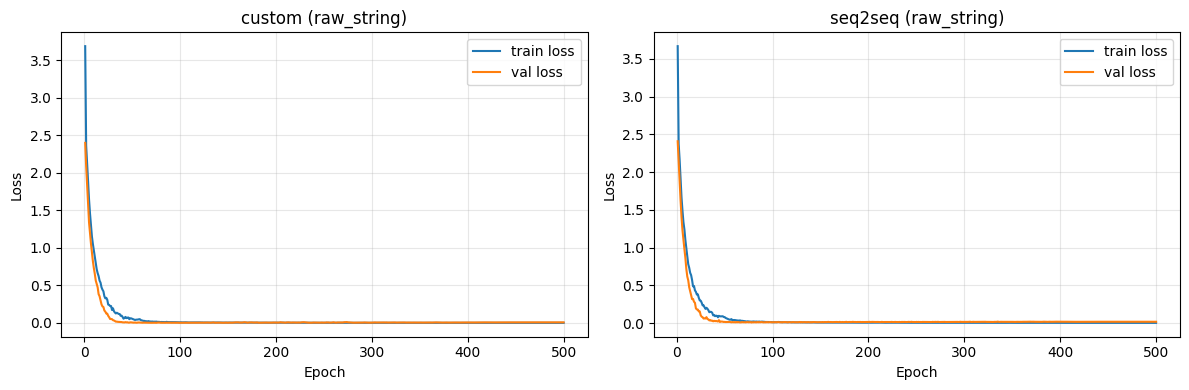

PosixPath('/kaggle/working/kaggle_custom_qcd_fd2sq/loss_curves/raw_string_loss_curves.png')

In [6]:
raw_results, raw_histories = run_suite(TARGET_VARIANT_RAW_STRING)
display(raw_results[SUMMARY_COLUMNS])
plot_suite_losses(TARGET_VARIANT_RAW_STRING, raw_results, raw_histories)


## Final Summary


In [7]:
final_summary_df = pd.concat([factorized_results, raw_results], ignore_index=True)
summary_small = final_summary_df[SUMMARY_COLUMNS]
summary_json = working_dir / "ablation_summary_all.json"
summary_md = working_dir / "ablation_summary_all.md"
summary_small.to_json(summary_json, orient="records", indent=2)
write_markdown_table(summary_small, summary_md, "Final Summary")
display(summary_small)
print(f"Saved summary to {summary_json}")
print(f"Saved markdown summary to {summary_md}")


,target_variant,variant_name,encoder_variant,max_target_len,split_seed,test_seq_accuracy
0,factorized,custom,custom,128,42,1.000000
1,factorized,seq2seq,seq2seq,128,42,0.791667
2,raw_string,custom,custom,1242,42,0.708333
3,raw_string,seq2seq,seq2seq,1242,42,0.416667


Saved summary to /kaggle/working/kaggle_custom_qcd_fd2sq/ablation_summary_all.json
Saved markdown summary to /kaggle/working/kaggle_custom_qcd_fd2sq/ablation_summary_all.md


## Observation

What I notice here is that the audited tree-level QCD 2-to-2 dataset closes to a small finite family of simplified `color_factor` terms and `denominator` forms. 

The audited `color_factor` classes are:

```text
16/9
2
2/3
3/4
64/27
8/3
```

The audited denominator classes are:

```text
(2*m_b^2 + reg_prop + 2*s_12)^2
(2*m_b^2 + reg_prop - 2*s_13)^2
(2*m_c^2 + reg_prop + 2*s_12)^2
(2*m_c^2 + reg_prop - 2*s_13)^2
(2*m_d^2 + reg_prop + 2*s_12)^2
(2*m_d^2 + reg_prop - 2*s_13)^2
(2*m_s^2 + reg_prop + 2*s_12)^2
(2*m_s^2 + reg_prop - 2*s_13)^2
(2*m_t^2 + reg_prop + 2*s_12)^2
(2*m_t^2 + reg_prop - 2*s_13)^2
(2*m_u^2 + reg_prop + 2*s_12)^2
(2*m_u^2 + reg_prop - 2*s_13)^2
(reg_prop + 2*s_12)^2
(reg_prop - 2*s_13)^2
(reg_prop - 2*s_23)^2
```

For the QCD notebooks, that observation lines up with the usual color-basis and Casimir-basis perspective. The finite factor side comes from a restricted set of basis combinations in the present 2-to-2 tree-level scope `{C_F^2, C_A^2, C_F*C_A}`, while the denominator side comes from the equally restricted propagator topologies in the diagrams.

If I extend this later, the interesting question is how these observed finite families change once I move beyond 2-to-2 tree level, allow more external legs, or include loops. We can explore methods including Casimir-basis etc. 

References:
- [L. Dixon, *Calculating Scattering Amplitudes Efficiently* (1996)](https://arxiv.org/abs/hep-ph/9601359)
- [V. Del Duca, L. Dixon, F. Maltoni, *New Color Decompositions for Gauge Amplitudes at Tree and Loop Level* (1999)](https://arxiv.org/abs/hep-ph/9910563)
- [H. Johansson, A. Ochirov, *Color-Kinematics Duality for QCD Amplitudes* (2015)](https://arxiv.org/abs/1507.00332)
- [S. Catani, *The Singular Behaviour of QCD Amplitudes at Two-Loop Order* (1998)](https://arxiv.org/abs/hep-ph/9802439)


In [8]:
observation_summary_df = observation_summary(data_dir)
observation_json = working_dir / "observation_summary.json"
observation_md = working_dir / "observation_summary.md"
observation_summary_df.to_json(observation_json, orient="records", indent=2)
write_markdown_table(observation_summary_df, observation_md, "Observation Summary")
display(observation_summary_df)
print(f"Saved observation summary to {observation_json}")
print(f"Saved observation markdown to {observation_md}")


  Parsed QCD-2-to-2-diag-TreeLevel-0.txt: 46 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-1.txt: 42 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-2.txt: 38 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-3.txt: 34 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-4.txt: 30 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-5.txt: 26 diagrams
  Parsed QCD-2-to-2-diag-TreeLevel-6.txt: 18 diagrams
Total QCD diagrams: 234


,num_samples,unique_color_factors,unique_denominators
0,234,6,15


Saved observation summary to /kaggle/working/kaggle_custom_qcd_fd2sq/observation_summary.json
Saved observation markdown to /kaggle/working/kaggle_custom_qcd_fd2sq/observation_summary.md


## Thank you!
Please mail me at sreenandan.shashidharan@gmail.com or at 24JE0701@iitism.ac.in if anything is amiss. I sincerely apologise in advance. 